# Set environment

In [8]:
### Basic
import numpy  as np
import scipy  as sc
import pandas as pd
import glob, os, re
import pickle, sys
import math
import timeit

### CUDA
from numba import cuda, vectorize

### plotting
import matplotlib.pyplot as plt
plt.style.use('seaborn-darkgrid')

In [2]:
%matplotlib inline

# Smoothing with CUDA

In [3]:
### define a point type
point_dtype = np.dtype({
    'names':   ['x', 'y'],
    'formats': [np.float32, np.float32]})

### calculate squared distance
@cuda.jit(device = True)
def dist2_kernel(point1, point2):
    return math.pow(point1["x"] - point2["x"], 2) + math.pow(point1["y"] - point2["y"], 2)

### convert squared distance into exponential
@cuda.jit(device = True)
def dist2weight_kernel(dist2, sig2 = 1):
    #if (kernel == "standard normal"):
    return math.exp(-1 * dist2 / sig2)

### wrap function of distance and weight function
### signature: point_dtype[:], point_dtype[:], float[:, :]
@cuda.jit
def get_weights(grids, points, weights, sig2 = 1):
    # set index of cuda
    idx_grid, idx_point = cuda.grid(2)
    if (idx_grid < weights.shape[0]) & (idx_point < weights.shape[1]):
        # intialization
        grid  = grids[idx_grid]
        point = points[idx_point]
        
        # calculate distance and then convert to weights
        dist2 = dist2_kernel(grid, point)
        weights[idx_grid, idx_point] = dist2weight_kernel(dist2, sig2)

####################################################
### helper function: convert coordinate into point
def set_points(dat_pts):
    """Convert data frame of coordinates to an array of points
    
    >>> tmp = np.arange(10).reshape(-1, 2)
    >>> set_points(tmp)
    ... array([(0., 1.), (2., 3.), (4., 5.), (6., 7.), (8., 9.)],
      dtype=[('x', '<f8'), ('y', '<f8')])
    >>> set_points(tmp)[0]['x'], set_points(tmp)[0]['y']
    ... (0.0, 1.0)
    """
    ### initialization
    num_pts = dat_pts.shape[0]
    points = np.empty((num_pts,), dtype = point_dtype)
    
    ### convert each row into a point
    for idx in range(num_pts):
        p = points[idx]
        p['x'], p['y'] = dat_pts[idx][0], dat_pts[idx][1]
    
    return points

####################################################
def get_coord_grid(coord, ngrid):
    """create grid from coordination of k samples"""
    ### Coordinate
    x = coord[:, 0]
    y = coord[:, 1]
        
    ### set coordinate of grids
    xc = np.linspace(min(x), max(x), ngrid)
    yc = np.linspace(min(y), max(y), ngrid)
    xc, yc = np.meshgrid(xc, yc)
        
    ### the return grids coordinate with shape (ngrid x ngrid, 2)
    grids = np.array([xc.ravel(), yc.ravel()]).T
    assert grids.shape == (ngrid**2, 2)
    return grids

####################################################
def ksmooth_cuda(matrix, coord, sig2, ngrid, threadsperblock = (32, 32)):
    ### Coordinate from dimensional reduction
    points = set_points(coord)
            
    ### generate a grid of a frame
    grids = get_coord_grid(coord, ngrid)
    grids = set_points(grids)
            
    ### cuda memory blocks
    blockspergrid_x = math.ceil(grids.shape[0]  / threadsperblock[0])
    blockspergrid_y = math.ceil(points.shape[0] / threadsperblock[1])
    blockspergrid = (blockspergrid_x, blockspergrid_y)
            
    ### calculate the weights for smoothing
    weights = np.empty(shape = (grids.shape[0], points.shape[0]), dtype = np.float32)
    get_weights[blockspergrid, threadsperblock](grids, points, weights, sig2)
            
    ### for each feature, generate each frame and store in an image
    img = []
    nr, nc = matrix.shape
    for idx_feature in range(nc):
        # kernel smoothing
        z = matrix[:, idx_feature]
        zc = np.matmul(weights, z)
        
        # store into a list "img"
        img.append(zc)
        
    img = np.array(img)
    return img.T

# Smoothing without CUDA

In [4]:
def dist2_fun(point1, point2):
    return math.pow(point1["x"] - point2["x"], 2) + math.pow(point1["y"] - point2["y"], 2)

def dist2weight(dist2, sig2 = 1):
    return math.exp(-1 * dist2 / sig2)

def get_weights2(grids, points, weights, sig2 = 1):
    for idx_grid in range(weights.shape[0]):
        grid  = grids[idx_grid]
        
        for idx_point in range(weights.shape[1]):
            point = points[idx_point]
        
            # calculate distance and then convert to weights
            dist2 = dist2_fun(grid, point)
            weights[idx_grid, idx_point] = dist2weight(dist2, sig2)
        
####################################################
def ksmooth(matrix, coord, sig2, ngrid):
    ### generate a grid of a frame
    grids = get_coord_grid(coord, ngrid)
    
    ### set points
    grids  = set_points(grids)
    points = set_points(coord)
                    
    # calculate the weights for smoothing
    weights = np.empty(shape = (grids.shape[0], points.shape[0]), dtype = np.float32)
    get_weights2(grids, points, weights, sig2)
    ################################
            
    # for each feature, generate each frame and store in an image
    img = []
    nr, nc = matrix.shape
    
    #for idx_feature in range(dat.get_num_variable()):
    for idx_feature in range(nc):
        # interpolation
        z = matrix[:, idx_feature]
        zc = np.matmul(weights, z)
        
        # store into a list "img"
        img.append(zc)
        
    # collect the image of each sample
    img = np.array(img)
    #lst_img.append(img.T)
    return img.T

# simulated data

In [5]:
def generate_sample(mean, cov, num_events):
    """sample from guassian mixed model"""
    assert mean.shape[0] == cov.shape[0]
    assert mean.shape[0] == num_events.shape[0]
    
    num_clusters = mean.shape[0]
    dat = [np.random.multivariate_normal(mean[idx], cov[idx], num_events[idx]) for idx in range(num_clusters)]
    dat = np.concatenate(dat)
    return dat

In [9]:
### Generate data
np.random.seed(123)
mu = np.array([[0, 0],[5, 5]])        ### Mean
sd = np.array([np.eye(2), np.eye(2)]) ### SD
nc = np.array([[1 * idx, 9 * idx] for idx in [1, 2, 5, 10, 15, 20, 25, 50, 100]])
nc

array([[  1,   9],
       [  2,  18],
       [  5,  45],
       [ 10,  90],
       [ 15, 135],
       [ 20, 180],
       [ 25, 225],
       [ 50, 450],
       [100, 900]])

In [10]:
np.random.seed(123)
y = np.array([generate_sample(mu, sd, nc[idx]) for idx in range(len(nc))])
[x.shape for x in y]

[(10, 2),
 (20, 2),
 (50, 2),
 (100, 2),
 (150, 2),
 (200, 2),
 (250, 2),
 (500, 2),
 (1000, 2)]

In [11]:
%time img1 = ksmooth_cuda(mat, y, 2, 128, threadsperblock=(16, 16))

CPU times: user 147 ms, sys: 253 ms, total: 400 ms
Wall time: 190 ms


In [8]:
%time img1 = ksmooth_cuda(mat, y, 2, 128, threadsperblock=(32, 32))

CPU times: user 182 ms, sys: 186 ms, total: 368 ms
Wall time: 186 ms


# get the time

In [11]:
lst = []
niter = 10

for idx in range(len(nc)):
    ###
    mat = np.array([1] * nc[idx].sum()).reshape(-1, 1)
    
    ###
    dt = timeit.timeit(
        lambda: ksmooth_cuda(
            mat, y[idx], 2, 128, 
            threadsperblock=(32, 32)),
        number=niter)
    
    ###
    lst.append(dt / niter)
    
lst_dt_cuda = np.array(lst)
print(lst_dt_cuda)

[0.07092461 0.03917077 0.04570868 0.04677497 0.0487374  0.05482367
 0.05406245 0.09151756 0.17006179]


In [12]:
lst = []
niter = 10

for idx in range(len(nc)):
    ###
    mat = np.array([1] * nc[idx].sum()).reshape(-1, 1)
    
    ###
    dt = timeit.timeit(
        lambda: ksmooth(
            mat, y[idx], 2, 128),
        number=niter)
    
    ###
    lst.append(dt / niter)
    
lst_dt = np.array(lst)
print(lst_dt)

[ 0.42769469  0.78581504  1.86829173  3.67503286  5.48427179  7.37121972
  9.10227131 18.47643387 36.76336846]


In [22]:
plt.style.use("seaborn-whitegrid")

Text(0,0.5,'Time (s)')

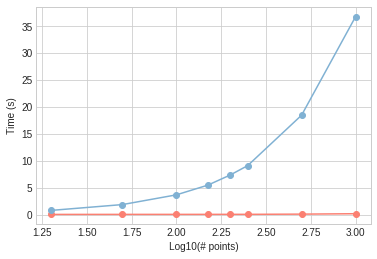

In [26]:
num = np.log10(nc.sum(axis = 1))
#x   = np.log10(lst_dt_cuda[1:])
#y   = np.log10(lst_dt[1:])
x = lst_dt_cuda[1:]
y = lst_dt[1:]

plt.plot(num[1:], x, 'o-', color = "#fb8072")
plt.plot(num[1:], y, 'o-', color = "#80b1d3")
plt.xlabel("Log10(# points)")
plt.ylabel("Time (s)")

In [31]:
nc[0].sum()

10

In [35]:
idx = 0
mat = np.array([1] * nc[0].sum()).reshape(-1, 1)
niter = 30
dt = timeit.timeit(
    lambda: ksmooth_cuda(mat, y[idx], 2, 128, threadsperblock=(32, 32)),
    number=niter)
dt_mu = dt / niter

0.04463450923309817